<a href="https://colab.research.google.com/github/ben-blake/umkc-deep-learning/blob/main/hw2-cnn/HW2-formal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 2 - Convolutional Neural Network and Recurrent Neural Networks**

In this homework, you are required to build a convolutional neural network a recursive neural network for image classification, possibly with some advanced training tips.

**Name:** Ben Blake

**Student ID:** 14387365

## **About the Dataset**

The dataset used here is Fashion-MNIST, a collection of food images in 10 classes.

Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.

We intend Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.

## **Import Packages**

First, we need to import packages that will be used later.

In this homework, we highly rely on **torchvision**, a library of PyTorch.

In [6]:
# Import necessary packages.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn  # All neural network modules, nn.Linear, nn.Conv2d, BatchNorm, Loss functions
import torch.optim as optim  # For all Optimization algorithms, SGD, Adam, etc.
import torch.nn.functional as F  # All functions that don't have any parameters
from torch.utils.data import (DataLoader,)  # Gives easier dataset managment and creates mini batches
import torchvision  # torch package for vision related things
import torchvision.datasets as datasets  # Has standard datasets we can import in a nice way
import torchvision.transforms as transforms  # Transformations we can perform on our dataset
from PIL import Image

# This is for the progress bar.
from tqdm.auto import tqdm

%matplotlib inline

## **Dataset, Data Loader, and Transforms**

Torchvision provides lots of useful utilities for image preprocessing, data wrapping as well as data augmentation.

Here, since our data are stored in folders by class labels, we can directly apply **torchvision.datasets.DatasetFolder** for wrapping data without much effort.

Please refer to [PyTorch official website](https://pytorch.org/vision/stable/transforms.html) for details about different transforms.

In [7]:
# Transforms
my_transforms = transforms.Compose(
    [
     transforms.ToTensor(),
     ]
)

# Here is another example of transforms
# This transform is not optimal!
# my_transforms = transforms.Compose(
#     [  # Compose makes it possible to have many transforms
#         transforms.Resize((36, 36)),  # Resizes (32,32) to (36,36)
#         transforms.RandomCrop((28, 28)),  # Takes a random (28,28) crop
#         transforms.ColorJitter(brightness=0.5),  # Change brightness of image
#         transforms.RandomRotation(
#             degrees=45
#         ),  # Perhaps a random rotation from -45 to 45 degrees
#         transforms.RandomHorizontalFlip(
#             p=0.5
#         ),  # Flips the image horizontally with probability 0.5
#         transforms.RandomVerticalFlip(
#             p=0.05
#         ),  # Flips image vertically with probability 0.05
#         transforms.RandomGrayscale(p=0.2),  # Converts to grayscale with probability 0.2
#         transforms.ToTensor(),  # Finally converts PIL image to tensor so we can train w. pytorch
#         transforms.Normalize(
#             mean=0.5, std=0.5
#         ),  # Note: these values aren't optimal
#     ]
# )

# Download the dataset
train_dataset = datasets.FashionMNIST(
    root="dataset/", train=True, transform=my_transforms, download=True
)
val_dataset = datasets.FashionMNIST(
    root="dataset/", train=False, transform=my_transforms,download=True
)
test_dataset = datasets.FashionMNIST(
    root="dataset/", train=False, transform=my_transforms,download=True
)

# Load Data
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

## Data Visulization

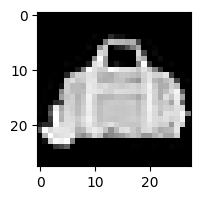

In [8]:
# Random pick a sample to plot
sample = next(iter(train_loader))
imgs, lbls = sample

# Plot the sample
plt.figure(figsize=(2,2))
grid = torchvision.utils.make_grid(nrow=20, tensor=imgs[1])
plt.imshow(np.transpose(grid, axes=(1,2,0)), cmap='gray');

## **Convolutional Neural Network**

###  CNN Model (7pts)

In [9]:
# Simple CNN
class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super(CNN, self).__init__()
        #(1pt)TODO: Fill the missing with correct number
        # conv2 below is declared with in_channels=8, so conv1 has to emit 8
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=8, # hint: in_channels of next conv layer
            kernel_size=(3, 3),
            stride=(1, 1),
            padding=(1, 1),
        )

        #(1pt)TODO: Use a Max Pooling layer with kernel size = 2 and stride =2
        # one instance reused for both pooling steps in forward
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=(3, 3),
            stride=(1, 1),
            padding=(1, 1),
        )
        #(1pt)TODO: Fill the missing with correct number
        # 3x3 kernels with padding=1 keep the spatial size, so only the two pools
        # shrink it: 28 -> 14 -> 7. With conv2's 16 channels that's 16*7*7 = 784.
        self.fc1 = nn.Linear(16 * 7 * 7, num_classes) # hint: feature channels * length * width

    def forward(self, x):
        # same conv -> relu -> pool order as the conv2 block below
        x = self.conv1(x) #(1pt)TODO: Use conv1 layer defined above
        x = F.relu(x) #(1pt)TODO: Use relu layer
        x = self.pool(x) #(1pt)TODO: Use pooling layer defined above
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        # reshape above already flattened to (batch, 784), which is what fc1 expects
        x = self.fc1(x) #(1pt)TODO: Use fully connection layer defined above
        return x

### Hyperparameters, Data loader and Loss (1pt)

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
learning_rate = 1e-4
batch_size = 64
num_epochs = 10 # You may change number of epochs here. 10 epochs may take up to 10 minutes for training.

# Load pretrain model & you may modify it
model = CNN(in_channels=1, num_classes=10)
model.classifier = nn.Sequential(nn.Linear(512, 100), nn.ReLU(), nn.Linear(100, 10))
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss() # (1pt)TODO: Use CrossEntropy as loss criterion
# combines log_softmax + NLL, so it takes the raw logits from fc1 directly
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


### Training

In [11]:
# Train Network
for epoch in range(num_epochs):
    losses = []

    for batch_idx, (data, targets) in enumerate(train_loader):
        # Get data to cuda if possible
        data = data.to(device=device)
        targets = targets.to(device=device)

        # forward
        scores = model(data)
        loss = criterion(scores, targets)

        losses.append(loss.item())
        # backward
        optimizer.zero_grad()
        loss.backward()

        # gradient descent or adam step
        optimizer.step()

    print(f"Loss at epoch {epoch + 1} is {sum(losses)/len(losses):.5f}")

Loss at epoch 1 is 1.12983
Loss at epoch 2 is 0.62305
Loss at epoch 3 is 0.54650
Loss at epoch 4 is 0.50307
Loss at epoch 5 is 0.47514
Loss at epoch 6 is 0.45621
Loss at epoch 7 is 0.44088
Loss at epoch 8 is 0.42920
Loss at epoch 9 is 0.41928
Loss at epoch 10 is 0.41077


### Check Accuracy

In [12]:
# Check accuracy on training & test to see how good our model
def check_accuracy(loader, model):
    if loader.dataset.train:
        print("Checking accuracy on training data")
    else:
        print("Checking accuracy on test data")

    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device)
            y = y.to(device=device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

        print(
            f"Got {num_correct} / {num_samples} with accuracy {float(num_correct)/float(num_samples)*100:.2f}"
        )

    model.train()

check_accuracy(train_loader, model)
check_accuracy(val_loader, model)

Checking accuracy on training data
Got 51353 / 60000 with accuracy 85.59
Checking accuracy on test data
Got 8487 / 10000 with accuracy 84.87


## **A simple Recurrent Neural Networks, GRU, LSTM on the MNIST dataset**


### Recurrent Neural Networks (2pts)

In [13]:
# Recurrent neural network (many-to-one)
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size * sequence_length, num_classes)

    def forward(self, x):
        # Set initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Forward propagate LSTM
        out, _ = self.rnn(x, h0)
        out = out.reshape(out.shape[0], -1) # (1pt)TODO: Reshape the output
        # out is (batch, 28, hidden_size); flatten the time axis so each sample is
        # one hidden_size * sequence_length vector, matching fc's input size

        # Decode the hidden state of the last time step
        out = self.fc(out) # (1pt)TODO: Use fully connected laers above
        return out

### Gated Recurrent Unit Recurrent Neural Networks(GRU)

In [14]:
# Recurrent neural network with GRU (many-to-one)
class RNN_GRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size * sequence_length, num_classes)

    def forward(self, x):
        # Set initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Forward propagate LSTM
        out, _ = self.gru(x, h0)
        out = out.reshape(out.shape[0], -1)

        # Decode the hidden state of the last time step
        out = self.fc(out)
        return out

### Long Short-Term Memory (4pts)

In [15]:
# Recurrent neural network with LSTM (many-to-one)

# Compared the model above and fill the following missings
class RNN_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) # (1pt)TODO: Define LSTM layer
        # same constructor signature as nn.GRU above; batch_first so input is (batch, seq, feature)
        self.fc = nn.Linear(hidden_size * sequence_length, num_classes) # (1pt)TODO: Define fc layer
        # same as GRU: fc reads all 28 timesteps at once, not just the last one

    def forward(self, x):
        # Set initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Forward propagate LSTM
        out, _ = self.lstm(
            x, (h0, c0)
        )  # out: tensor of shape (batch_size, seq_length, hidden_size)
        out = out.reshape(out.shape[0], -1) # (1pt)TODO: Reshape the output
        # flatten time axis into the feature axis to match fc's input size

        # Decode the hidden state of the last time step
        out = self.fc(out) # (1pt)TODO: Use fc layer above
        return out

### Training (1pt)

In [16]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
input_size = 28
hidden_size = 256
num_layers = 3
num_classes = 10
sequence_length = 28
learning_rate = 0.005
batch_size = 64
num_epochs = 3

# Load Data
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

# Initialize network (try out just using simple RNN, or GRU, and then compare with LSTM)
model_RNN = RNN(input_size, hidden_size, num_layers, num_classes).to(device)
model_GRU = RNN_GRU(input_size, hidden_size, num_layers, num_classes).to(device)
model_LSTM = RNN_LSTM(input_size, hidden_size, num_layers, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_RNN = optim.Adam(model_RNN.parameters(), lr=learning_rate)
optimizer_GRU = optim.Adam(model_GRU.parameters(), lr=learning_rate)
optimizer_LSTM = optim.Adam(model_LSTM.parameters(), lr=learning_rate)


# Train Network
# RNN
print('RNN Training')
for epoch in range(num_epochs):
    for batch_idx, (data, targets) in enumerate(tqdm(train_loader)):
        # Get data to cuda if possible
        data = data.to(device=device).squeeze(1)
        targets = targets.to(device=device)

        # forward
        scores_RNN = model_RNN(data)
        loss_RNN= criterion(scores_RNN, targets)

        # backward
        optimizer_RNN.zero_grad()
        loss_RNN.backward()

        # gradient descent update step/adam step
        optimizer_RNN.step()

# RNN_GRU
print('RNN_GRU Training')
for epoch in range(num_epochs):
    for batch_idx, (data, targets) in enumerate(tqdm(train_loader)):
        # Get data to cuda if possible
        data = data.to(device=device).squeeze(1)
        targets = targets.to(device=device)

        # forward
        scores_GRU = model_GRU(data)
        loss_GRU= criterion(scores_GRU, targets)

        # backward
        optimizer_GRU.zero_grad()
        loss_GRU.backward()

        # gradient descent update step/adam step
        optimizer_GRU.step()

# RNN_LSTM
print('RNN_LSTM Training')
for epoch in range(num_epochs):
    for batch_idx, (data, targets) in enumerate(tqdm(train_loader)):
        # Get data to cuda if possible
        data = data.to(device=device).squeeze(1)
        targets = targets.to(device=device)

        # forward
        scores_LSTM = model_LSTM(data)
        loss_LSTM= criterion(scores_LSTM, targets) # (1pt)TODO: Calculate loss by using criterion
        # same (logits, targets) call as the RNN and GRU loops above

        # backward
        optimizer_LSTM.zero_grad()
        loss_LSTM.backward()

        # gradient descent update step/adam step
        optimizer_LSTM.step()



RNN Training


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

RNN_GRU Training


...

  0%|          | 0/938 [00:00<?, ?it/s]

RNN_LSTM Training


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

### Check Accuracy (1pt)

In [17]:
# Check accuracy on training & test to see how good our model
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0

    # Set model to eval
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device).squeeze(1)
            y = y.to(device=device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum() # (1pt)TODO: Count the number of correct prediction
            # elementwise compare gives a bool tensor; sum() counts the hits in this batch
            num_samples += predictions.size(0)

    # Toggle model back to train
    model.train()
    return num_correct / num_samples


print(f"RNN_Accuracy on training set: {check_accuracy(train_loader, model_RNN)*100:2f}")
print(f"RNN_Accuracy on test set: {check_accuracy(test_loader, model_RNN)*100:.2f}")
print(f"RNN_GRU_Accuracy on training set: {check_accuracy(train_loader, model_GRU)*100:2f}")
print(f"RNN_GRU_Accuracy on test set: {check_accuracy(test_loader, model_GRU)*100:.2f}")
print(f"RNN_LSTM_Accuracy on training set: {check_accuracy(train_loader, model_LSTM)*100:2f}")
print(f"RNN_LSTM_Accuracy on test set: {check_accuracy(test_loader, model_LSTM)*100:.2f}")

RNN_Accuracy on training set: 49.850002
RNN_Accuracy on test set: 49.40
RNN_GRU_Accuracy on training set: 88.086662
RNN_GRU_Accuracy on test set: 86.80
RNN_LSTM_Accuracy on training set: 89.401665
RNN_LSTM_Accuracy on test set: 87.57


# **Summary**

**CNN.** conv1 (1→8) → ReLU → 2x2 max pool → conv2 (8→16) → ReLU → pool → fc(784→10). Loss 1.1298 at epoch 1 down to 0.4108 at epoch 10, still falling when it stopped. 85.59% train / 84.87% test. Only 9,098 parameters sit in the forward path; `model.classifier` adds another 52,310 that `forward` never calls, so they go into the optimizer and never receive a gradient.

**Flatten size.** 3x3 kernels with padding=1 leave H and W unchanged, so only the two pools shrink the map: 28 → 14 → 7. With conv2's 16 channels that is 16\*7\*7 = 784 into fc1.

**RNN vs GRU vs LSTM.** Same setup for all three: input 28, hidden 256, 3 layers, 28 timesteps, lr 0.005, 3 epochs.

| model | params | train | test |
|---|---|---|---|
| RNN | 408,074 | 49.85 | 49.40 |
| GRU | 1,080,842 | 88.09 | 86.80 |
| LSTM | 1,417,226 | 89.40 | 87.57 |

The plain RNN lands at about half the accuracy of the gated models. 28 timesteps through 3 stacked tanh layers is deep enough for gradients to vanish, and lr 0.005 is high for it. GRU and LSTM have the gate paths to carry gradient, so they train fine at that same setting. LSTM beats GRU by 0.77 on test for 31% more parameters.

**Overfitting.** Train/test gaps are small everywhere: 0.72 CNN, 0.45 RNN, 1.29 GRU, 1.83 LSTM. Nothing is overfitting yet, and the three recurrent models only saw 3 epochs.

**Note on the split.** `val_dataset` and `test_dataset` are both `FashionMNIST(train=False)` — the same 10,000 images, checked elementwise. Validation accuracy in the CNN section is therefore test accuracy, which is also why `check_accuracy(val_loader, model)` prints "Checking accuracy on test data". No held-out set to tune against.

**Takeaway.** Gating matters more than capacity. The RNN has 408k parameters and gets 49.40; the CNN has 9,098 and gets 84.87, roughly 45x fewer parameters for 35 points more accuracy. Convolution's spatial prior fits a 28x28 image better than reading it as a 28-step sequence of rows.

#**AI Use Disclosure**

Anthropic Claude Code was utilized on this assignment. Its contributions were: assistance with the explanatory comments next to updated TODO items and the summary. All code outside the TODO markers is the provided template, unmodified. I personally modified, reviewed, and ran the final notebook.

#**Documentation Referenced**

**CNN:**
- nn.Conv2d - https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- nn.MaxPool2d - https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html
- nn.Linear - https://pytorch.org/docs/stable/generated/torch.nn.Linear.html
- F.relu - https://pytorch.org/docs/stable/generated/torch.nn.functional.relu.html

**Recurrent models:**
- nn.RNN - https://pytorch.org/docs/stable/generated/torch.nn.RNN.html
- nn.GRU - https://pytorch.org/docs/stable/generated/torch.nn.GRU.html
- nn.LSTM - https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html
- Tensor.reshape (flattening the time axis before fc) - https://pytorch.org/docs/stable/generated/torch.Tensor.reshape.html

**Loss, training & evaluation:**
- nn.CrossEntropyLoss - https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- torch.optim.Adam - https://pytorch.org/docs/stable/generated/torch.optim.Adam.html
- torch.no_grad - https://pytorch.org/docs/stable/generated/torch.no_grad.html
- Tensor.max (pulling the predicted class) - https://pytorch.org/docs/stable/generated/torch.Tensor.max.html
- nn.Module.eval - https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.eval

**Dataset:**
- torchvision.datasets.FashionMNIST - https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html